Mounted at /content/drive
Training set size: 10592 samples
Testing set size: 2648 samples
Training initial XGBoost model...
Initial XGBoost model training complete.

Initial XGBoost Model Performance:
Root Mean Squared Error (RMSE): 274.7762
R-squared (R2): -0.5714


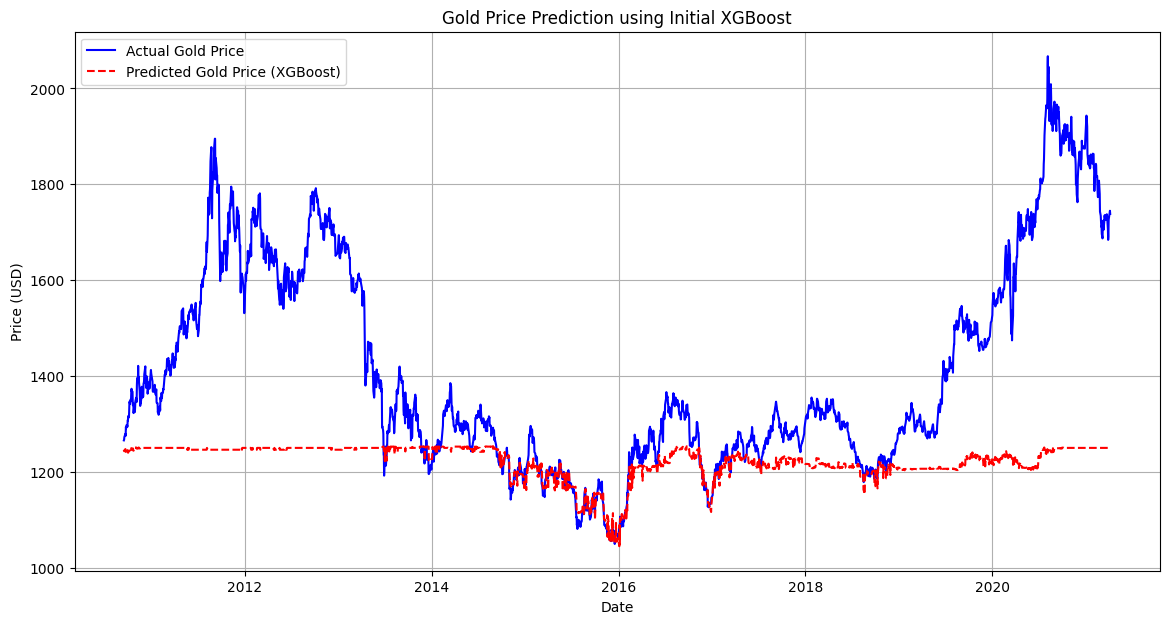


Starting XGBoost Hyperparameter Tuning...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
XGBoost Hyperparameter Tuning Complete.
Best XGBoost parameters: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.6}

Tuned XGBoost Model Performance:
Root Mean Squared Error (RMSE): 278.0268
R-squared (R2): -0.6088


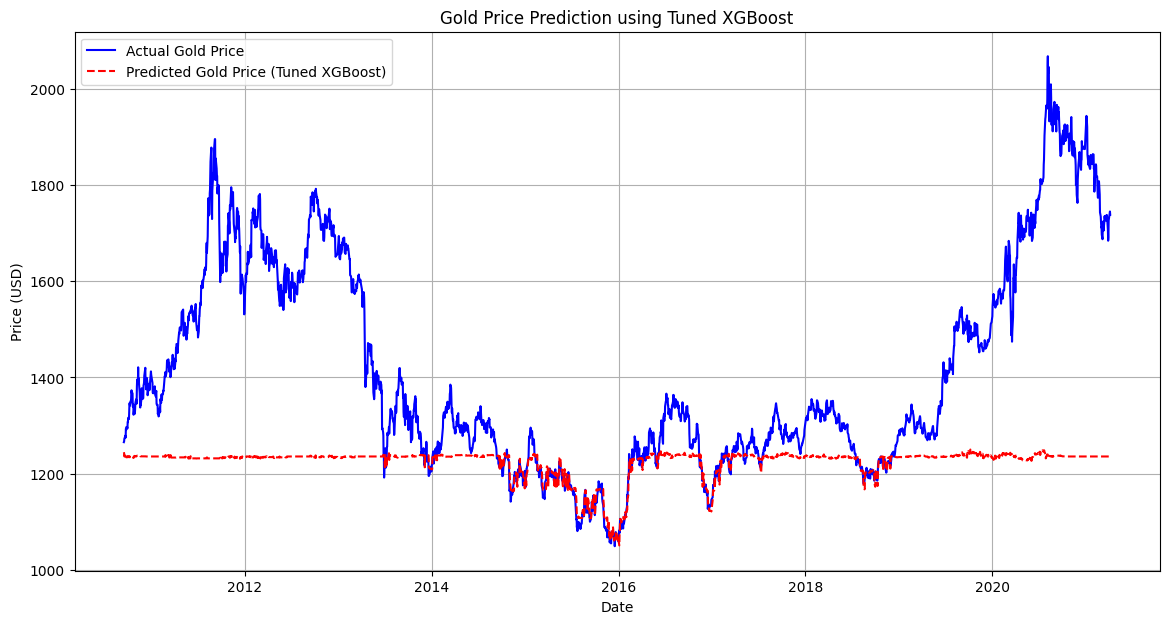

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from google.colab import drive

# --- 1. Mount Google Drive and Load Data ---
drive.mount('/content/drive', force_remount=True) # force_remount to ensure it's always mounted
base_path = '/content/drive/MyDrive/d2'
gold_price_path = f"{base_path}/gold_price.csv"
silver_price_path = f"{base_path}/silver_price.csv"

try:
    gold_df = pd.read_csv(gold_price_path)
    silver_df = pd.read_csv(silver_price_path)
except FileNotFoundError as e:
    print(f"Error loading data: {e}")
    # Handle error, maybe exit or raise
    raise

# --- 2. Clean and Merge Data ---
gold_df_cleaned = gold_df.dropna(subset=['price']).copy()
silver_df_cleaned = silver_df.dropna(subset=['price']).copy()

gold_df_cleaned['date'] = pd.to_datetime(gold_df_cleaned['date'])
silver_df_cleaned['date'] = pd.to_datetime(silver_df_cleaned['date'])

gold_df_cleaned = gold_df_cleaned.set_index('date')
silver_df_cleaned = silver_df_cleaned.set_index('date')

merged_df = pd.merge(gold_df_cleaned, silver_df_cleaned, on='date', suffixes=('_gold', '_silver'))

# --- 3. Feature Engineering and Data Split for ML ---
merged_df = merged_df.sort_index()
target = 'price_gold'
lags = [1, 2, 3, 7, 14, 30, 60]
for col in ['price_gold', 'price_silver']:
    for lag in lags:
        merged_df[f'{col}_lag_{lag}'] = merged_df[col].shift(lag)

df_ml = merged_df.dropna().copy()

X = df_ml.drop(columns=[target, 'price_silver']) # Drop original prices, keep lags
y = df_ml[target]

split_point = int(len(df_ml) * 0.8)
X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

# --- 4. Initial XGBoost Model Training and Evaluation ---
print("Training initial XGBoost model...")
xgb_regressor = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, random_state=42)
xgb_regressor.fit(X_train, y_train)
print("Initial XGBoost model training complete.")

# Make predictions on the test set
y_pred_xgb = xgb_regressor.predict(X_test)

# Evaluate the model
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"\nInitial XGBoost Model Performance:")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.4f}")
print(f"R-squared (R2): {r2_xgb:.4f}")

# Plot actual vs predicted prices for initial XGBoost
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test, label='Actual Gold Price', color='blue')
plt.plot(y_test.index, y_pred_xgb, label='Predicted Gold Price (XGBoost)', color='red', linestyle='--')
plt.title('Gold Price Prediction using Initial XGBoost')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

# --- 5. XGBoost Hyperparameter Tuning ---
print("\nStarting XGBoost Hyperparameter Tuning...")

xgb_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

xgb_random_search = RandomizedSearchCV(
    xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
    param_distributions=xgb_param_dist,
    n_iter=20,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

xgb_random_search.fit(X_train, y_train)

print("XGBoost Hyperparameter Tuning Complete.")
print(f"Best XGBoost parameters: {xgb_random_search.best_params_}")

# Evaluate the best XGBoost model
best_xgb_model = xgb_random_search.best_estimator_
y_pred_xgb_tuned = best_xgb_model.predict(X_test)

rmse_xgb_tuned = np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned))
r2_xgb_tuned = r2_score(y_test, y_pred_xgb_tuned)

print(f"\nTuned XGBoost Model Performance:")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb_tuned:.4f}")
print(f"R-squared (R2): {r2_xgb_tuned:.4f}")

# Plot actual vs predicted prices for tuned XGBoost
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test, label='Actual Gold Price', color='blue')
plt.plot(y_test.index, y_pred_xgb_tuned, label='Predicted Gold Price (Tuned XGBoost)', color='red', linestyle='--')
plt.title('Gold Price Prediction using Tuned XGBoost')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [2]:
# --- 3.1. Enhanced Feature Engineering ---

# Calculate Daily Returns for gold and silver
merged_df['gold_daily_return'] = merged_df['price_gold'].pct_change()
merged_df['silver_daily_return'] = merged_df['price_silver'].pct_change()

# Calculate Moving Averages for gold prices
merged_df['gold_sma_5'] = merged_df['price_gold'].rolling(window=5).mean()
merged_df['gold_sma_20'] = merged_df['price_gold'].rolling(window=20).mean()
merged_df['gold_sma_50'] = merged_df['price_gold'].rolling(window=50).mean()

# Recalculate df_ml after adding new features, ensuring to drop NaNs from new features as well
df_ml_enhanced = merged_df.dropna().copy()

# Define features (X) and target (y)
# We drop the original gold and silver prices and keep all lagged and new features
X_enhanced = df_ml_enhanced.drop(columns=[target, 'price_silver'])
y_enhanced = df_ml_enhanced[target]

# Re-split the data into training and testing sets
split_point_enhanced = int(len(df_ml_enhanced) * 0.8)
X_train_enhanced, X_test_enhanced = X_enhanced.iloc[:split_point_enhanced], X_enhanced.iloc[split_point_enhanced:]
y_train_enhanced, y_test_enhanced = y_enhanced.iloc[:split_point_enhanced], y_enhanced.iloc[split_point_enhanced:]

print(f"Training set size (enhanced): {len(X_train_enhanced)} samples")
print(f"Testing set size (enhanced): {len(X_test_enhanced)} samples")

display(X_train_enhanced.head())

Training set size (enhanced): 10592 samples
Testing set size (enhanced): 2648 samples


,price_gold_lag_1,price_gold_lag_2,price_gold_lag_3,price_gold_lag_7,price_gold_lag_14,price_gold_lag_30,price_gold_lag_60,price_silver_lag_1,price_silver_lag_2,price_silver_lag_3,price_silver_lag_7,price_silver_lag_14,price_silver_lag_30,price_silver_lag_60,gold_daily_return,silver_daily_return,gold_sma_5,gold_sma_20,gold_sma_50
date,,,,,,,,,,,,,,,,,,,
1968-06-27,40.85,40.95,40.90,41.10,41.25,40.25,37.70,2.493,2.512,2.483,2.431,2.478,2.401,2.259,0.001224,-0.000401,40.93,41.2350,40.430
1968-06-28,40.90,40.85,40.95,41.40,41.30,41.25,37.30,2.492,2.493,2.512,2.534,2.446,2.459,2.202,0.000000,0.004013,40.90,41.1825,40.497
1968-07-01,40.90,40.90,40.85,41.10,41.55,41.50,37.60,2.502,2.492,2.493,2.468,2.506,2.505,2.195,-0.002445,0.003997,40.88,41.1250,40.560
1968-07-02,40.80,40.90,40.90,41.05,41.90,42.30,36.95,2.512,2.502,2.492,2.449,2.576,2.506,2.125,0.002451,-0.019506,40.87,41.1125,40.618
1968-07-03,40.90,40.80,40.90,40.90,41.30,42.40,37.00,2.463,2.512,2.502,2.483,2.520,2.554,2.104,0.003667,0.010556,40.91,41.1050,40.671


### Exploring Recurrent Neural Networks (RNNs) with LSTMs

Given the limitations of traditional models like XGBoost and Prophet for capturing complex time-series dynamics, we will now turn to deep learning, specifically Long Short-Term Memory (LSTM) networks. LSTMs are a type of Recurrent Neural Network (RNN) that are particularly effective for sequential data, capable of learning long-term dependencies, and can better handle the non-linear and evolving patterns in financial time series like gold prices.

We will need to prepare the data in a sequence-based format, build and train an LSTM model, and then evaluate its performance.

Trial 180 Complete [00h 03m 43s]
val_loss: 0.0001640932314330712

Best val_loss So Far: 2.7944828616455197e-05
Total elapsed time: 08h 09m 24s

LSTM Hyperparameter Tuning Complete.
Optimal number of units in the first LSTM layer: 96
Optimal dropout rate in the first LSTM layer: 0.1
Optimal number of units in the second LSTM layer: 96
Optimal dropout rate in the second LSTM layer: 0.4
Optimal learning rate for the Adam optimizer: 0.001
Epoch 1/50
265/265 ━━━━━━━━━━━━━━━━━━━━ 20s 59ms/step - loss: 4.8763e-04 - val_loss: 7.3013e-04
Epoch 2/50
265/265 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step - loss: 2.1339e-04 - val_loss: 0.0019
Epoch 3/50
265/265 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step - loss: 1.5464e-04 - val_loss: 0.0011
Epoch 4/50
265/265 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step - loss: 1.2030e-04 - val_loss: 5.2684e-04
Epoch 5/50
265/265 ━━━━━━━━━━━━━━━━━━━━ 14s 54ms/step - loss: 1.1377e-04 - val_loss: 4.1480e-04
Epoch 6/50
265/265 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step - loss: 8.4380e-05 - val_loss: 2.04

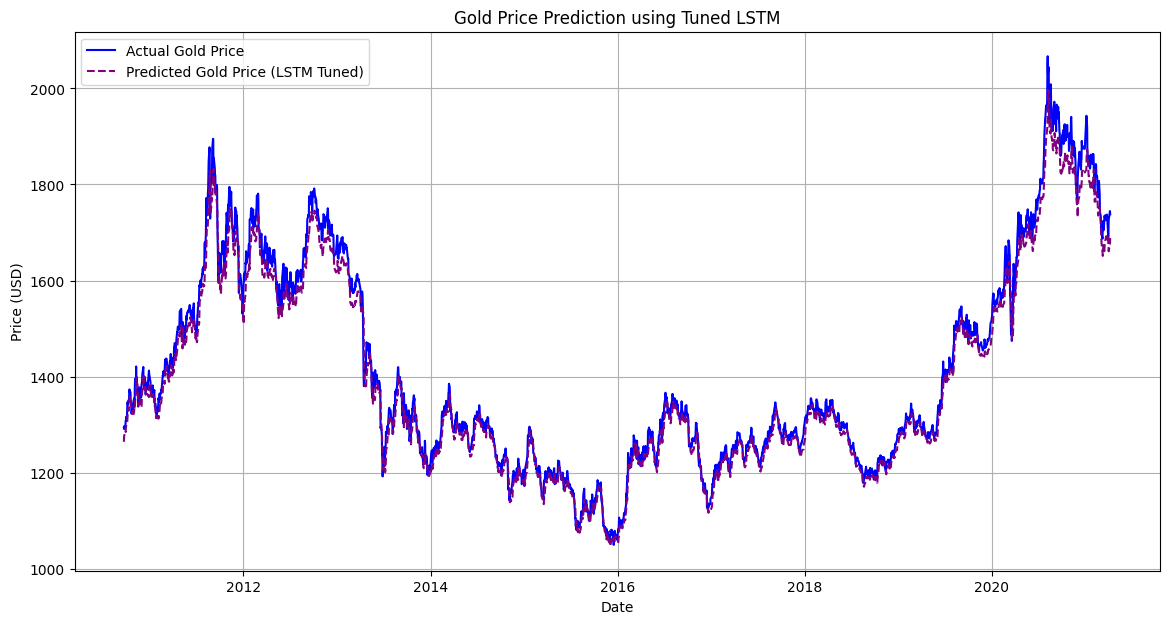

In [9]:
!pip install keras-tuner

import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import keras_tuner as kt

# --- 7.1. Data Preparation for LSTM ---
# LSTM models typically perform better with scaled data

# Combine X_enhanced and y_enhanced into a single DataFrame for scaling
df_for_lstm = df_ml_enhanced.copy()

# Select features relevant for LSTM. Let's include gold price, silver price, and the engineered features
# target = 'price_gold' will be 'y'
# X will be all other selected features

# For simplicity, let's use a subset of features including gold price itself, silver price and some lags and MAs
selected_features_lstm = ['price_gold', 'price_silver', 'gold_daily_return', 'silver_daily_return',
                          'gold_sma_5', 'gold_sma_20', 'gold_sma_50']

# Add lagged gold prices as features for LSTM
for lag in lags:
    selected_features_lstm.append(f'price_gold_lag_{lag}')

df_lstm = df_for_lstm[selected_features_lstm].copy()
df_lstm = df_lstm.dropna() # Drop any remaining NaNs from feature selection

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_lstm)

# Define sequence length for LSTM (how many past days to look at to predict the next day)
sequence_length = 30 # For example, use past 30 days to predict the next day

X_lstm, y_lstm = [], []
for i in range(sequence_length, len(scaled_data)):
    X_lstm.append(scaled_data[i-sequence_length:i, :])
    y_lstm.append(scaled_data[i, selected_features_lstm.index('price_gold')]) # Predict the gold price

X_lstm, y_lstm = np.array(X_lstm), np.array(y_lstm)

# Split data into training and testing sets
# Use a similar split point as before to maintain consistency
split_point_lstm = int(len(X_lstm) * 0.8)
X_train_lstm, X_test_lstm = X_lstm[:split_point_lstm], X_lstm[split_point_lstm:]
y_train_lstm, y_test_lstm = y_lstm[:split_point_lstm], y_lstm[split_point_lstm:]

print(f"LSTM Training set shape: {X_train_lstm.shape}")
print(f"LSTM Testing set shape: {X_test_lstm.shape}")

# --- 7.2. Build and Train LSTM Model ---
print("\nBuilding and training LSTM model...")

# Define a model-building function for Keras Tuner
def build_lstm_model(hp):
    model = Sequential()
    model.add(LSTM(units=hp.Int('units_1', min_value=32, max_value=128, step=32),
                   return_sequences=True,
                   input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
    model.add(Dropout(hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)))
    model.add(LSTM(units=hp.Int('units_2', min_value=32, max_value=128, step=32),
                   return_sequences=False))
    model.add(Dropout(hp.Float('dropout_2', min_value=0.1, max_value=0.5, step=0.1)))
    model.add(Dense(units=1)) # Output layer for predicting one value (gold price)

    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    model.compile(optimizer=Adam(learning_rate=hp_learning_rate), loss='mean_squared_error')
    return model

# Initialize the Keras Tuner
tuner = kt.Hyperband(
    build_lstm_model,
    objective='val_loss',
    max_epochs=50,
    factor=3,
    hyperband_iterations=2,
    directory='my_dir',
    project_name='lstm_gold_price_tuning',
    overwrite=True
)

# Use EarlyStopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Search for the best hyperparameters
print("\nStarting LSTM Hyperparameter Tuning...")
tuner.search(X_train_lstm, y_train_lstm, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stopping], verbose=1)

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\nLSTM Hyperparameter Tuning Complete.")
print(f"Optimal number of units in the first LSTM layer: {best_hps.get('units_1')}")
print(f"Optimal dropout rate in the first LSTM layer: {best_hps.get('dropout_1')}")
print(f"Optimal number of units in the second LSTM layer: {best_hps.get('units_2')}")
print(f"Optimal dropout rate in the second LSTM layer: {best_hps.get('dropout_2')}")
print(f"Optimal learning rate for the Adam optimizer: {best_hps.get('learning_rate')}")

# Build the best model and train it
model_lstm = tuner.hypermodel.build(best_hps)
history = model_lstm.fit(X_train_lstm, y_train_lstm, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stopping], verbose=1)
print("LSTM model training complete with best hyperparameters.")

# --- 7.3. Make Predictions and Evaluate LSTM Model ---

# Make predictions on the test set
y_pred_lstm_scaled = model_lstm.predict(X_test_lstm)

# Inverse transform the predictions to get actual gold prices
# We need to create a dummy array with the same number of features as the original scaled data
# to inverse transform correctly, then extract only the 'price_gold' column
y_test_lstm_inverse = scaler.inverse_transform(np.concatenate((np.zeros((len(y_test_lstm), len(selected_features_lstm)-1)), y_test_lstm.reshape(-1,1)), axis=1))[:, -1]
y_pred_lstm_inverse = scaler.inverse_transform(np.concatenate((np.zeros((len(y_pred_lstm_scaled), len(selected_features_lstm)-1)), y_pred_lstm_scaled), axis=1))[:, -1]

# Evaluate the model
rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm_inverse, y_pred_lstm_inverse))
r2_lstm = r2_score(y_test_lstm_inverse, y_pred_lstm_inverse)

print(f"\nLSTM Model Performance (Tuned):")
print(f"Root Mean Squared Error (RMSE): {rmse_lstm:.4f}")
print(f"R-squared (R2): {r2_lstm:.4f}")

# Plot actual vs predicted prices for LSTM
plt.figure(figsize=(14, 7))
# The dates for the test set need to be aligned correctly with the predictions
# The original df_ml_enhanced index can be used after adjusting for sequence_length and split_point_lstm
test_dates_lstm = df_lstm.index[sequence_length + split_point_lstm:]

plt.plot(test_dates_lstm, y_test_lstm_inverse, label='Actual Gold Price', color='blue')
plt.plot(test_dates_lstm, y_pred_lstm_inverse, label='Predicted Gold Price (LSTM Tuned)', color='purple', linestyle='--')
plt.title('Gold Price Prediction using Tuned LSTM')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

LSTM Model Description and Procedure
1. What is an LSTM? Long Short-Term Memory (LSTM) is a type of Recurrent Neural Network (RNN) particularly well-suited for processing and predicting sequences, like time series data. Unlike traditional feedforward neural networks, LSTMs have 'memory cells' that can retain information over long periods, making them effective at capturing long-term dependencies in data. This capability makes them ideal for financial time series, where past price movements can influence future ones.

2. Why was LSTM Chosen? Previous attempts with XGBoost and Prophet models yielded poor results (negative R-squared scores), indicating they struggled to capture the complex, non-linear, and time-dependent patterns in gold prices. LSTMs were introduced as a deep learning approach known for their ability to handle such complex sequential data and potentially offer better predictive power.

3. Data Preparation for LSTM (Section 7.1): * Feature Selection: A specific set of features was chosen, including price_gold, price_silver, gold_daily_return, silver_daily_return, and several Simple Moving Averages (gold_sma_5, gold_sma_20, gold_sma_50). Additionally, lagged gold prices (e.g., price_gold_lag_1, price_gold_lag_2, etc.) were included as features to provide historical context. * Scaling: LSTM models are sensitive to the scale of input data, so the selected features were scaled to a range between 0 and 1 using MinMaxScaler. This helps the model converge faster and perform better. * Sequence Creation: The scaled data was transformed into sequences. For each prediction point, the model looks back sequence_length (set to 30) days. So, X_lstm contains sequences of 30 days of feature data, and y_lstm is the gold price of the next day corresponding to that sequence. * Train-Test Split: The sequential data was split into training and testing sets (80% train, 20% test) to maintain consistency with previous models.

4. Model Architecture (Section 7.2 - build_lstm_model function): The LSTM model is a sequential model built with Keras and consists of: * Two LSTM Layers: These are the core recurrent layers. The first LSTM layer has return_sequences=True because it feeds into another LSTM layer. The second LSTM layer has return_sequences=False as it's the last recurrent layer before the output. * Dropout Layers: Placed after each LSTM layer, Dropout layers are used to prevent overfitting by randomly setting a fraction of input units to 0 at each update during training. * Dense Output Layer: A final Dense layer with a single unit (neuron) predicts the gold price. This is a linear activation as we are predicting a continuous value. * Optimizer and Loss: The model is compiled using the Adam optimizer and mean_squared_error as the loss function, which is standard for regression tasks.

5. Hyperparameter Tuning (Section 7.2): * Keras Tuner with the Hyperband algorithm was employed to find the optimal architecture and training parameters for the LSTM model. * Tunable Parameters: The parameters being tuned included: * units_1 and units_2: The number of LSTM units (neurons) in each of the two LSTM layers (ranging from 32 to 128). * dropout_1 and dropout_2: The dropout rates for the dropout layers (ranging from 0.1 to 0.5). * learning_rate: The learning rate for the Adam optimizer (choices: 0.01, 0.001, 0.0001). * Early Stopping: During tuning and final training, EarlyStopping was used to monitor the val_loss (validation loss) and stop training if the loss didn't improve for 10 consecutive epochs, preventing overfitting and saving computation time.

6. Training (Section 7.2): * The tuner.search method was used to conduct the hyperparameter search, automatically training and evaluating different configurations. The best model was then built using the optimal hyperparameters found. * The best model was further trained on the X_train_lstm and y_train_lstm datasets for 50 epochs with a batch size of 32, again utilizing EarlyStopping.

7. Prediction and Evaluation (Section 7.3): * Prediction: The trained LSTM model makes predictions (y_pred_lstm_scaled) on the X_test_lstm data. * Inverse Transformation: Since the data was scaled before training, the predictions (y_pred_lstm_scaled) and the actual test values (y_test_lstm) are inverse transformed back to their original gold price scale for meaningful interpretation and evaluation. * Evaluation Metrics: The model's performance is evaluated using: * Root Mean Squared Error (RMSE): Measures the average magnitude of the errors. A lower RMSE indicates better accuracy. * R-squared (R2): Represents the proportion of the variance in the dependent variable that is predictable from the independent variables. An R2 closer to 1 indicates a better fit. * Visualization: A plot is generated to visually compare the Actual Gold Price against the Predicted Gold Price (LSTM Tuned) on the test set, allowing for a qualitative assessment of the model's performance.
